Jakie są najbardziej oczekiwane umiejętności w 3 najpopularniejszych stanowisk

-- Ładowanie danych i zmiana kolumny z umiejętnościami 

In [1]:
import ast 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
from datasets import load_dataset

f:\Dokumenty\Nauka\luk_python\.venv-luke\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:


def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)

#loading data
datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(clean_list)

wybranie danych dla 3 stanowisk

In [14]:
job_titles = df['job_title_short'].value_counts().head(3).index.to_list()

In [17]:
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

In [15]:
df_T3_US = df[(df['job_country'] == 'United States') & (df['job_title_short'].isin(job_titles))]

zestawienie umiejętności dla tych 3 stanowisk

In [16]:
df_T3_skills = df_T3_US.explode('job_skills')

In [6]:
df_T3_skills_gb = df_T3_skills.groupby(['job_title_short', 'job_skills']).size().reset_index(name='count').sort_values('count', ascending=False)

In [7]:
df_job_counts = df_T3_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [8]:
df_T3_skills_gb =df_T3_skills_gb.merge(df_job_counts, on='job_title_short')


Top 5 umiejętności dla danej roli oraz obliczenie procentowego występowania umiejętności w ogłoszeniach 

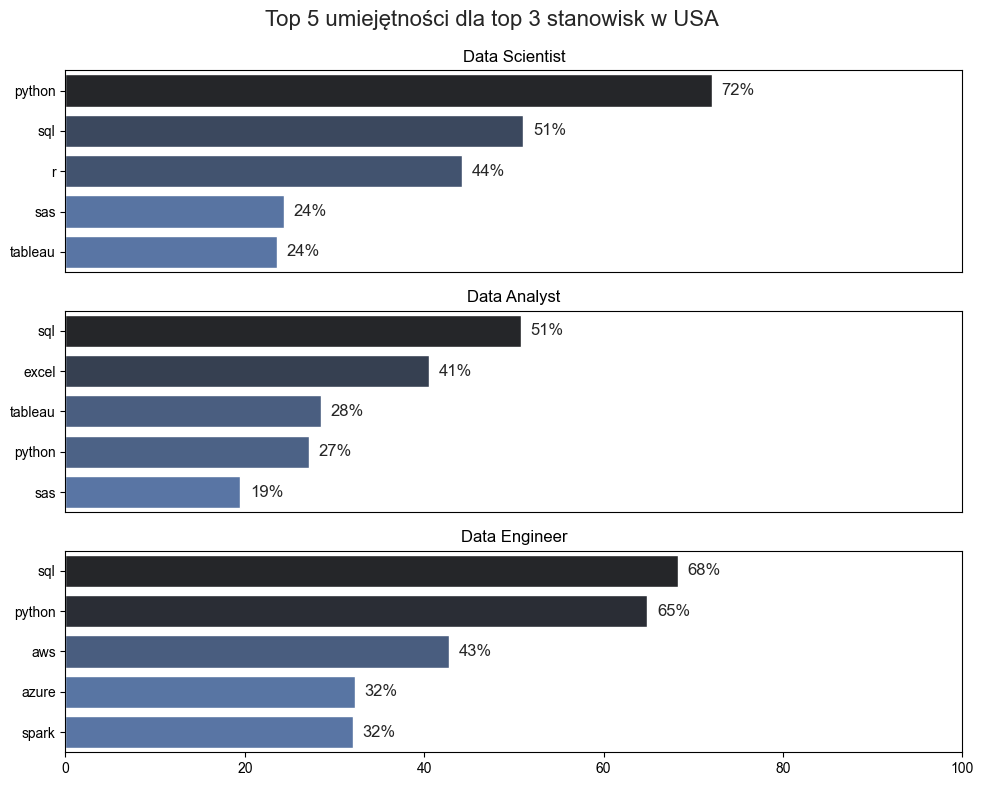

In [9]:
fig, ax = plt.subplots(3,1, figsize=(10, 8))

for i, role in enumerate(job_titles):
    df_one_role = df_T3_skills_gb[df_T3_skills_gb['job_title_short'] == role]
    df_one_role['skill_percentage'] = (df_one_role['count'] / df_one_role['jobs_total']) * 100
    sns.set_theme(style="ticks")
    sns.barplot(
        data=df_one_role.head(5),
        x='skill_percentage',
        y='job_skills',
        ax=ax[i],
        hue='skill_percentage',
        palette='dark:b_r',
        legend=False
    )
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_title(f'{role}')
    ax[i].set_xlim(0, 100)
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.0f%%', padding=7)

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
fig.suptitle('Top 5 umiejętności dla top 3 stanowisk w USA', fontsize=16)
plt.tight_layout()
plt.show()
